In [1]:
!pip install openai-whisper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 13.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 92.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 67.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 71.0 MB/

In [2]:
!pip install jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 37.6 MB/s eta 0:00:00


In [3]:
# import whisper
# import torch
# import tempfile
# import pandas as pd
# from jiwer import wer


# # Load model once
# model = whisper.load_model("base")

# def transcribe_audio(audio_input):
#     """Transcribe audio from file path or file object"""
#     if isinstance(audio_input, str):
#         result = model.transcribe(audio_input)
#         return result.get("text", "")
    
#     with tempfile.NamedTemporaryFile(delete=False, suffix=".wav") as tmp:
#         tmp.write(audio_input.read())
#         tmp_path = tmp.name
    
#     result = model.transcribe(tmp_path)
#     return result.get("text", "")

# # Load CSV with reference transcripts
# df = pd.read_csv("/kaggle/input/call-center-transcripts-dataset/call_recordings.csv")

# # Store results
# results = []

# # Loop through all 20 recordings
# for i in range(1, 21):
#     audio_path = f"/kaggle/input/call-center-transcripts-dataset/call_recording_{i:02d}.wav"
    
#     # Get hypothesis (Whisper transcription)
#     hypothesis = transcribe_audio(audio_path)
    
#     # Get reference (ground truth from CSV)
#     # Assuming the transcript is in column index 6
#     reference = df.iloc[i-1].iloc[6]
    
#     # Calculate WER
#     error = wer(reference, hypothesis)
    
#     results.append({
#         'recording': f'call_recording_{i:02d}.wav',
#         'wer': error,
#         'reference': reference,
#         'hypothesis': hypothesis
#     })
    
#     print(f"Recording {i:02d} - WER: {error:.4f}")

# # Create results dataframe
# results_df = pd.DataFrame(results)

# # Summary statistics
# print("\n=== Summary ===")
# print(f"Average WER: {results_df['wer'].mean():.4f}")
# print(f"Median WER: {results_df['wer'].median():.4f}")
# print(f"Min WER: {results_df['wer'].min():.4f}")
# print(f"Max WER: {results_df['wer'].max():.4f}")



In [4]:
import os
import json
import pandas as pd

# Base directory
base_directory = '/kaggle/input/arxive-ninety-thousand'

# CSV output file
csv_file_path = 'call_recordings.csv'

# Create CSV with headers
print(f"Creating CSV file: {csv_file_path}\n")
df_header = pd.DataFrame(columns=['ID', 'transcript'])
df_header.to_csv(csv_file_path, index=False)

print("Processing transcripts...\n")

i = 0
error_count = 0

for root, dirs, files in os.walk(base_directory):
    json_files = [f for f in files if f.endswith('.json')]
    
    for jsonfile in json_files:
        # FIX: Join root path with filename
        file_path = os.path.join(root, jsonfile)
        
        try:
            with open(file_path, 'r', encoding='utf-8') as file:
                fulltext = json.load(file)  # FIX: Use json.load() not json.loads()
                text = fulltext.get("text") or fulltext.get("transcript") or str(fulltext)
            
            i += 1
            
            # Create dataframe row
            a = pd.DataFrame([[file_path, text]], columns=['ID', 'transcript'])
            a.to_csv(csv_file_path, mode='a', index=False, header=False)
            
            # Progress update
            if i % 500 == 0:
                print(f"✅ Processed {i:,} files...")
                
        except Exception as e:
            error_count += 1
            if error_count <= 10:
                print(f"❌ Error: {jsonfile}: {str(e)[:50]}")
            continue

print(f"\n{'='*60}")
print(f"✅ Total files processed: {i:,}")
print(f"❌ Errors encountered: {error_count:,}")
print(f"✅ Results saved to: {csv_file_path}")
print(f"{'='*60}")

# Show final result
df_final = pd.read_csv(csv_file_path)
print(f"\n📊 Total records: {len(df_final):,}")
print("\n📊 First 5 rows:")
print(df_final.head())

Creating CSV file: call_recordings.csv

Processing transcripts...

✅ Processed 500 files...
✅ Processed 1,000 files...
✅ Processed 1,500 files...
✅ Processed 2,000 files...
✅ Processed 2,500 files...
✅ Processed 3,000 files...
✅ Processed 3,500 files...
✅ Processed 4,000 files...
✅ Processed 4,500 files...
✅ Processed 5,000 files...
✅ Processed 5,500 files...
✅ Processed 6,000 files...
✅ Processed 6,500 files...
✅ Processed 7,000 files...
✅ Processed 7,500 files...
✅ Processed 8,000 files...
✅ Processed 8,500 files...
✅ Processed 9,000 files...
✅ Processed 9,500 files...
✅ Processed 10,000 files...
✅ Processed 10,500 files...
✅ Processed 11,000 files...
✅ Processed 11,500 files...
✅ Processed 12,000 files...
✅ Processed 12,500 files...
✅ Processed 13,000 files...
✅ Processed 13,500 files...
✅ Processed 14,000 files...
✅ Processed 14,500 files...
✅ Processed 15,000 files...
✅ Processed 15,500 files...
✅ Processed 16,000 files...
✅ Processed 16,500 files...
✅ Processed 17,000 files...
✅ 

In [5]:
pip install contractions


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.9/113.9 kB 8.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd
import contractions
import re
from nltk.corpus import stopwords
import nltk

# Install contractions with a reliable PyPI mirror to avoid connection errors
!pip install -i https://pypi.tuna.tsinghua.edu.cn/simple/ contractions

# Download NLTK stopwords
nltk.download('stopwords')

# --- Step 1: Load and clean the data ---
file_path = '/kaggle/working/call_recordings.csv'  # Update with your dataset path
df = pd.read_csv(file_path)

# Verify the columns
print("Columns in the dataset:", df.columns.tolist())


df['transcript'] = df['transcript'].fillna('')

# Perform text cleaning
# def clean_text(text):
#     text = contractions.fix(text)  # Expand contractions (e.g., "I'm" -> "I am")
#     text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove non-alphabetic characters
#     text = text.lower()  # Convert to lowercase
#     stop_words = set(stopwords.words('english'))  # Load stopwords
#     text = ' '.join([word for word in text.split() if word not in stop_words])  # Remove stopwords
#     return text


def minimal_clean(text):
    """Minimal cleaning that preserves sentiment signals"""
    if not isinstance(text, str) or pd.isna(text):
        return ''
    
    # Expand contractions (I'm -> I am, won't -> will not)
    text = contractions.fix(text)
    
    # Remove extra whitespace
    text = ' '.join(text.split())
    
    # Keep punctuation! Just remove special characters
    text = re.sub(r'[^a-zA-Z0-9\s.,!?\'-]', '', text)
    
    return text  # NO STOPWORD REMOVAL!


# Apply cleaning to the transcript column
df['cleaned_transcript'] = df['transcript'].apply(minimal_clean)

# --- Step 2: Output the cleaned dataset ---
# Select only ID and cleaned_transcript for the final DataFrame
df_cleaned = df[['ID', 'cleaned_transcript']].copy()

# Display basic info
print("\nDataset info after cleaning:")
print(df_cleaned.info())
print("\nSample cleaned data:")
print(df_cleaned.head())

# Optionally save the cleaned dataset to a CSV file
output_path = '/kaggle/working/cleaned_transcripts.csv'
df_cleaned.to_csv(output_path, index=False)
print(f"\nCleaned dataset saved to: {output_path}")



Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple/


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Columns in the dataset: ['ID', 'transcript']

Dataset info after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95944 entries, 0 to 95943
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   ID                  95944 non-null  object
 1   cleaned_transcript  95944 non-null  object
dtypes: object(2)
memory usage: 1.5+ MB
None

Sample cleaned data:
                                                  ID  \
0  /kaggle/input/arxive-ninety-thousand/medical_e...   
1  /kaggle/input/arxive-ninety-thousand/medical_e...   
2  /kaggle/input/arxive-ninety-thousand/medical_e...   
3  /kaggle/input/arxive-ninety-thousand/medical_e...   
4  /kaggle/input/arxive-ninety-thousand/medical_e...   

                                  cleaned_transcript  
0  Hello? Yes. Why did you hang up, sir? Pardon? ...  
1  Hello? Hello? Yes, hello, ma' am. Good afterno...  
2  Hello, good afternoon, this is PERSONNAME PERS...  
3

In [7]:
import shutil
import os

# Hugging Face cache location
cache_dir = os.path.expanduser("~/.cache/huggingface/hub")

# Find and remove the specific model
model_name = "models--cardiffnlp--twitter-roberta-base-sentiment-latest"
model_path = os.path.join(cache_dir, model_name)

if os.path.exists(model_path):
    shutil.rmtree(model_path)
    print(f"✅ Removed: {model_path}")
else:
    print(f"❌ Not found: {model_path}")




❌ Not found: /root/.cache/huggingface/hub/models--cardiffnlp--twitter-roberta-base-sentiment-latest


In [8]:
import pandas as pd
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

# Download VADER lexicon
nltk.download('vader_lexicon')

# Initialize VADER
sia = SentimentIntensityAnalyzer()

def vader_sentiment(text):
    if not isinstance(text, str):
        return 'neutral'
    
    scores = sia.polarity_scores(text)
    compound = scores['compound']
    
    if compound >= 0.2:
        return 'positive'
    elif compound <= -0.2:
        return 'negative'
    else:
        return 'neutral'

file_path = '/kaggle/working/cleaned_transcripts.csv'
df = pd.read_csv(file_path)

df['sentiment'] = df['cleaned_transcript'].apply(vader_sentiment)
df.to_csv('/kaggle/working/cleaned_transcripts_with_sentiment.csv', index=False)

print("✅ Sentiment column added successfully using VADER!")
print(df.head())

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


✅ Sentiment column added successfully using VADER!
                                                  ID  \
0  /kaggle/input/arxive-ninety-thousand/medical_e...   
1  /kaggle/input/arxive-ninety-thousand/medical_e...   
2  /kaggle/input/arxive-ninety-thousand/medical_e...   
3  /kaggle/input/arxive-ninety-thousand/medical_e...   
4  /kaggle/input/arxive-ninety-thousand/medical_e...   

                                  cleaned_transcript sentiment  
0  Hello? Yes. Why did you hang up, sir? Pardon? ...  positive  
1  Hello? Hello? Yes, hello, ma' am. Good afterno...  positive  
2  Hello, good afternoon, this is PERSONNAME PERS...  positive  
3  Hello? Yes, Hello, PERSONNAME. I am so sorry f...  positive  
4  Hello? Hello, can you speak with PERSONNAME PE...  positive  


In [9]:
import pandas as pd

# Read the new dataset
file_path = '/kaggle/working/cleaned_transcripts_with_sentiment.csv'
df = pd.read_csv(file_path)



print("\n SENTIMENT COUNTS:")
sentiment_counts = df['sentiment'].value_counts()
print(sentiment_counts)



 SENTIMENT COUNTS:
sentiment
positive    95474
negative      450
neutral        20
Name: count, dtype: int64


📊 ORIGINAL DISTRIBUTION:
sentiment
positive    95474
negative      450
neutral        20
Name: count, dtype: int64
Total samples: 95,944

📦 AVAILABLE SAMPLES:
Positive: 95,474
Negative: 450
Neutral: 20
✅ Negative samples upsampled from 450 to 95,474

✅ BALANCED TRAINING SET:
sentiment
positive    95474
negative    95474
neutral        20
Name: count, dtype: int64
Total training samples: 190,968


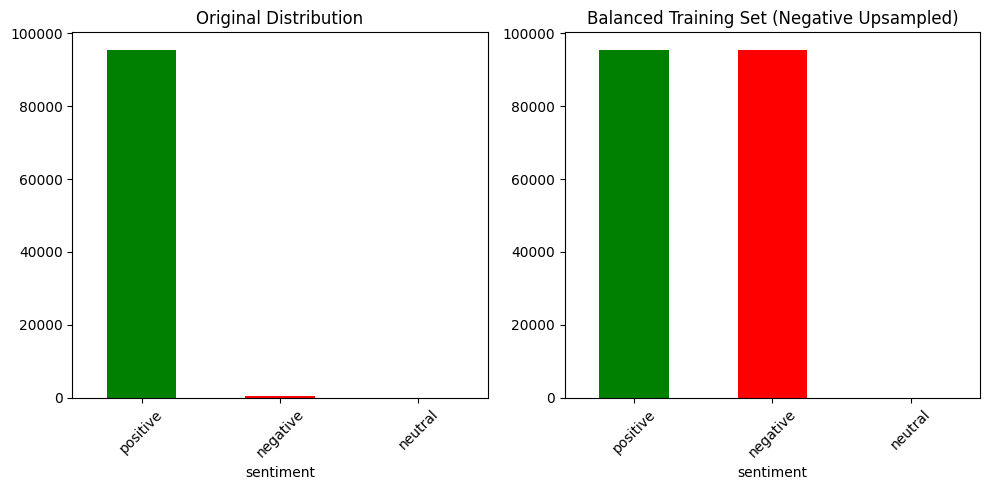

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
import matplotlib.pyplot as plt

print("📊 ORIGINAL DISTRIBUTION:")
print(df['sentiment'].value_counts())
print(f"Total samples: {len(df):,}")

# Create balanced dataset by upsampling negative
def create_balanced_training_set(df, max_samples_per_class=None, random_state=42):
    """
    Create a balanced training set by:
    - Sampling positive samples (or using all if max_samples_per_class is None)
    - Upsampling negative samples to match positive count
    - Keeping ALL neutral samples
    
    Args:
        max_samples_per_class: If set, limits the number of samples per class
    """
    # Separate classes
    positive_df = df[df['sentiment'] == 'positive']
    negative_df = df[df['sentiment'] == 'negative']
    neutral_df = df[df['sentiment'] == 'neutral']
    
    print(f"\n📦 AVAILABLE SAMPLES:")
    print(f"Positive: {len(positive_df):,}")
    print(f"Negative: {len(negative_df):,}")
    print(f"Neutral: {len(neutral_df):,}")
    
    # Sample positive class if limit is set
    if max_samples_per_class is not None and len(positive_df) > max_samples_per_class:
        positive_sampled = positive_df.sample(n=max_samples_per_class, random_state=random_state)
        print(f"📉 Positive samples limited to {max_samples_per_class:,}")
    else:
        positive_sampled = positive_df
    
    neutral_sampled = neutral_df
    
    # Upsample negative class to match positive count
    target_negative_count = len(positive_sampled)
    if len(negative_df) > 0:
        negative_upsampled = resample(
            negative_df,
            replace=True,  # Sample with replacement
            n_samples=target_negative_count,  # Match positive count
            random_state=random_state
        )
        print(f"✅ Negative samples upsampled from {len(negative_df):,} to {len(negative_upsampled):,}")
    else:
        print("❌ WARNING: No negative samples found!")
        negative_upsampled = negative_df
    
    # Combine into balanced dataset
    balanced_df = pd.concat([positive_sampled, negative_upsampled, neutral_sampled], 
                           ignore_index=True)
    
    # Shuffle the dataset
    balanced_df = balanced_df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    
    return balanced_df

# Create balanced dataset
balanced_df = create_balanced_training_set(df)

print(f"\n✅ BALANCED TRAINING SET:")
print(balanced_df['sentiment'].value_counts())
print(f"Total training samples: {len(balanced_df):,}")

# Visualize the new distribution
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
df['sentiment'].value_counts().plot(kind='bar', color=['green', 'red', 'blue'])
plt.title('Original Distribution')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
balanced_df['sentiment'].value_counts().plot(kind='bar', color=['green', 'red', 'blue'])
plt.title('Balanced Training Set (Negative Upsampled)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import re

# Set style for better visualizations
plt.style.use('default')
sns.set_palette("husl")
print("📊 EDA and Visualization Packages Loaded!")

📊 EDA and Visualization Packages Loaded!


In [12]:
print("🎯 BALANCED DATASET OVERVIEW")
print("=" * 60)
print(f"Dataset shape: {balanced_df.shape}")
print(f"Columns: {balanced_df.columns.tolist()}")
print(f"Missing values:\n{balanced_df.isnull().sum()}")


🎯 BALANCED DATASET OVERVIEW
Dataset shape: (190968, 3)
Columns: ['ID', 'cleaned_transcript', 'sentiment']
Missing values:
ID                    0
cleaned_transcript    0
sentiment             0
dtype: int64


In [13]:
# 1. BASIC SENTIMENT DISTRIBUTION
print("\n📈 1. SENTIMENT DISTRIBUTION ANALYSIS")
print("=" * 50)

sentiment_counts = balanced_df['sentiment'].value_counts()
sentiment_percentages = balanced_df['sentiment'].value_counts(normalize=True) * 100

print("Sentiment Distribution in Balanced Dataset:")
for sentiment, count in sentiment_counts.items():
    percentage = sentiment_percentages[sentiment]
    print(f"  {sentiment.upper()}: {count:,} samples ({percentage:.1f}%)")


📈 1. SENTIMENT DISTRIBUTION ANALYSIS
Sentiment Distribution in Balanced Dataset:
  POSITIVE: 95,474 samples (50.0%)
  NEGATIVE: 95,474 samples (50.0%)
  NEUTRAL: 20 samples (0.0%)


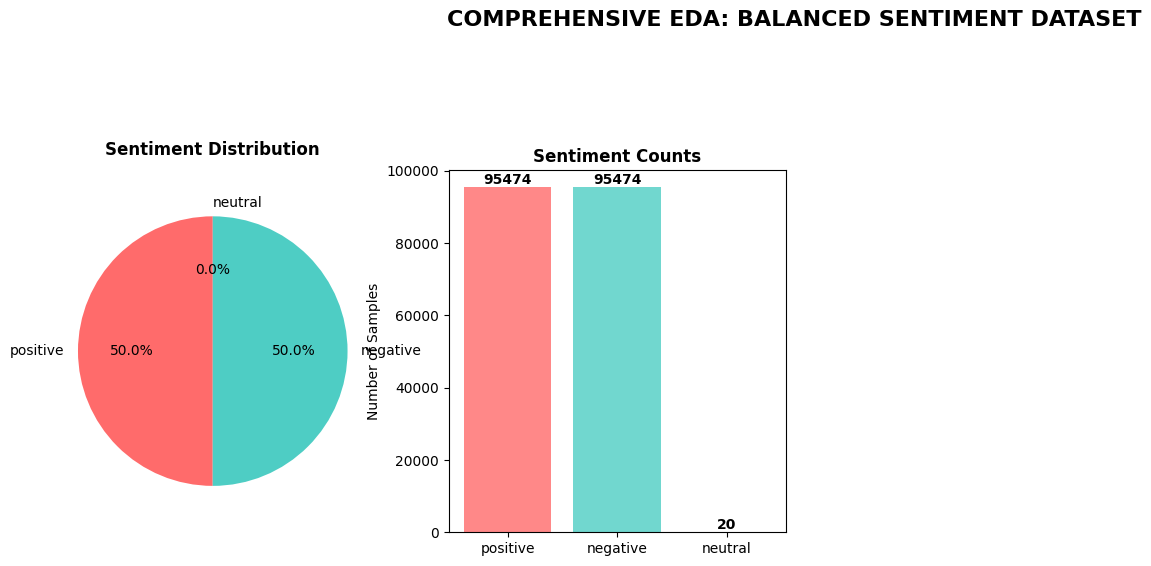

In [14]:
fig = plt.figure(figsize=(20, 16))
fig.suptitle('COMPREHENSIVE EDA: BALANCED SENTIMENT DATASET', fontsize=16, fontweight='bold')

# 1.1 Pie Chart - Sentiment Distribution
plt.subplot(3, 4, 1)
colors = ['#ff6b6b', '#4ecdc4', '#45b7d1']  # Red, Teal, Blue
wedges, texts, autotexts = plt.pie(sentiment_counts.values, labels=sentiment_counts.index, 
                                   autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Sentiment Distribution', fontweight='bold', pad=20)
# 1.2 Bar Plot - Sentiment Counts
plt.subplot(3, 4, 2)
bars = plt.bar(sentiment_counts.index, sentiment_counts.values, color=colors, alpha=0.8)
plt.title('Sentiment Counts', fontweight='bold')
plt.ylabel('Number of Samples')
for bar, count in zip(bars, sentiment_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             f'{count}', ha='center', va='bottom', fontweight='bold')
    

In [15]:
# 2. TEXT LENGTH ANALYSIS
print("\n📏 2. TEXT LENGTH ANALYSIS")
print("=" * 50)

# Calculate text statistics
balanced_df['word_count'] = balanced_df['cleaned_transcript'].apply(lambda x: len(str(x).split()))
balanced_df['char_count'] = balanced_df['cleaned_transcript'].apply(lambda x: len(str(x)))
balanced_df['sentence_count'] = balanced_df['cleaned_transcript'].apply(lambda x: len(str(x).split('.')))

print("Text Length Statistics by Sentiment:")
length_stats = balanced_df.groupby('sentiment')['word_count'].agg(['mean', 'median', 'std', 'min', 'max'])
print(length_stats.round(2))




📏 2. TEXT LENGTH ANALYSIS
Text Length Statistics by Sentiment:
             mean  median     std  min    max
sentiment                                    
negative   731.15   570.0  610.01    5   8219
neutral    123.75    53.0  152.59    1    576
positive   786.30   601.0  694.02    9  20016


Text(0, 0.5, 'Number of Characters')

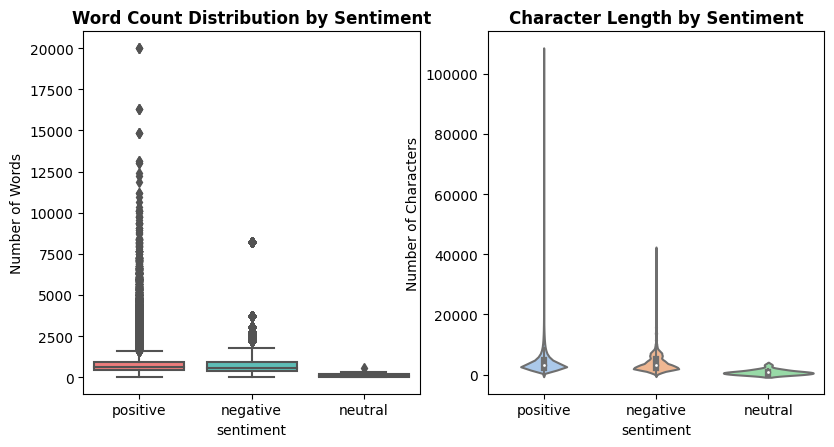

In [16]:
# 2.1 Box Plot - Word Count by Sentiment
fig = plt.figure(figsize=(20, 16))
plt.subplot(3, 4, 1)
sns.boxplot(data=balanced_df, x='sentiment', y='word_count', palette=colors)
plt.title('Word Count Distribution by Sentiment', fontweight='bold')
plt.ylabel('Number of Words')

# 2.2 Violin Plot - Character Count
plt.subplot(3, 4, 2)
sns.violinplot(data=balanced_df, x='sentiment', y='char_count', palette='pastel')
plt.title('Character Length by Sentiment', fontweight='bold')
plt.ylabel('Number of Characters')



🔤 3. TEXT COMPLEXITY ANALYSIS


Text(0, 0.5, 'Characters per Word')

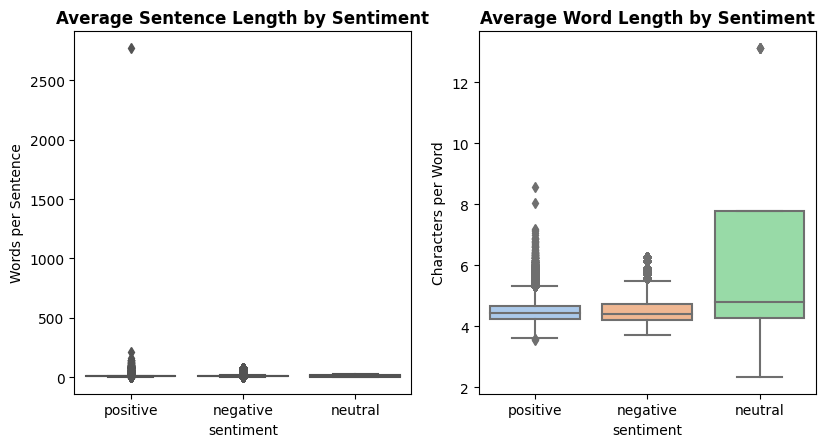

In [17]:
# 3. TEXT COMPLEXITY ANALYSIS
fig = plt.figure(figsize=(20, 16))
print("\n🔤 3. TEXT COMPLEXITY ANALYSIS")
print("=" * 50)

def calculate_readability_metrics(text):
    """Calculate basic readability metrics"""
    if not isinstance(text, str):
        return 0, 0
    
    words = text.split()
    sentences = text.split('.')
    
    if len(words) == 0 or len(sentences) == 0:
        return 0, 0
    
    avg_sentence_length = len(words) / len(sentences)
    avg_word_length = sum(len(word) for word in words) / len(words)
    
    return avg_sentence_length, avg_word_length

balanced_df[['avg_sentence_length', 'avg_word_length']] = balanced_df['cleaned_transcript'].apply(
    lambda x: pd.Series(calculate_readability_metrics(str(x)))
)

# 3.1 Average Sentence Length by Sentiment
plt.subplot(3, 4, 1)
sns.boxplot(data=balanced_df, x='sentiment', y='avg_sentence_length', palette=colors)
plt.title('Average Sentence Length by Sentiment', fontweight='bold')
plt.ylabel('Words per Sentence')

# 3.2 Average Word Length by Sentiment
plt.subplot(3, 4, 2)
sns.boxplot(data=balanced_df, x='sentiment', y='avg_word_length', palette='pastel')
plt.title('Average Word Length by Sentiment', fontweight='bold')
plt.ylabel('Characters per Word')


In [18]:
# Check what columns you actually have
print(df.columns)


Index(['ID', 'cleaned_transcript', 'sentiment'], dtype='object')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.4 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


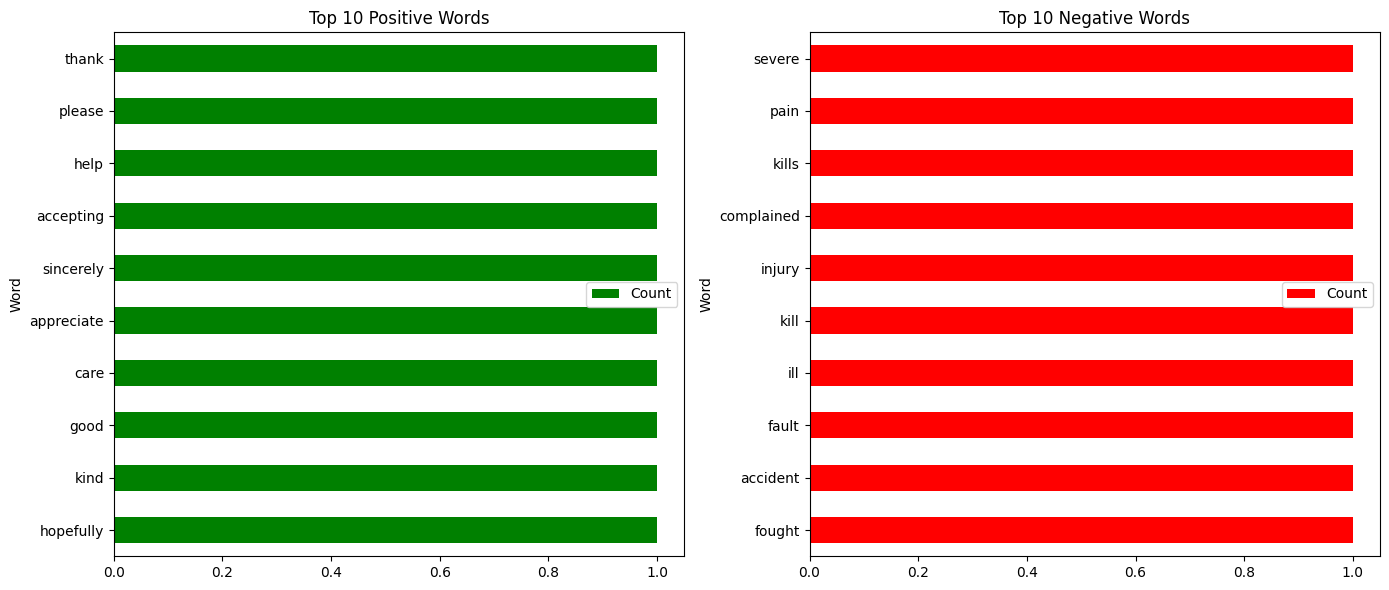

In [19]:
# ================================
# 📦 1. Add Negative Samples
# ================================
!pip install vaderSentiment

import random
import pandas as pd

# def add_negative_samples(df, n=200):
#     """
#     Create artificial negative samples by taking neutral examples
#     and appending clearly negative words for balance.
#     """
#     negative_words = [
#         "angry", "bad", "terrible", "disappointed", "frustrated",
#         "upset", "horrible", "issue", "complaint", "problem", "poor", "rude"
#     ]

#     # Ensure lowercase sentiment for matching
#     df["sentiment"] = df["sentiment"].str.lower()

#     # Pick neutral samples (or positive if few neutral)
#     neutral_subset = df[df["sentiment"] == "neutral"]
#     if len(neutral_subset) < n:
#         neutral_subset = df[df["sentiment"] == "positive"]

#     # Sample and modify
#     neutral_subset = neutral_subset.sample(min(n, len(neutral_subset)), random_state=42).copy()
#     neutral_subset["cleaned_transcript"] = neutral_subset["cleaned_transcript"].apply(
#         lambda x: x + " " + random.choice(negative_words)
#     )
#     neutral_subset["sentiment"] = "negative"

#     # Combine with original
#     df_aug = pd.concat([df, neutral_subset], ignore_index=True)
#     print("✅ Added", len(neutral_subset), "synthetic negative samples.")
#     print(df_aug["sentiment"].value_counts())
#     return df_aug

# df = add_negative_samples(df)

# ================================
# 💬 2. Improved Top 10 Words per Sentiment
# ================================

import nltk
from nltk.corpus import stopwords
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from collections import Counter
import matplotlib.pyplot as plt

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
analyzer = SentimentIntensityAnalyzer()

def get_sentiment_words(text, sentiment="pos"):
    words = [w for w in text.lower().split() if w.isalpha() and w not in stop_words]
    scored = {w: analyzer.polarity_scores(w)["compound"] for w in words}
    if sentiment == "pos":
        filtered = [w for w, s in scored.items() if s > 0.3]
    else:
        filtered = [w for w, s in scored.items() if s < -0.3]
    return filtered

# Combine text by sentiment
pos_text = " ".join(balanced_df[balanced_df["sentiment"] == "positive"]["cleaned_transcript"].tolist())
neg_text = " ".join(balanced_df[balanced_df["sentiment"] == "negative"]["cleaned_transcript"].tolist())

# Extract true sentiment words
pos_words = get_sentiment_words(pos_text, "pos")
neg_words = get_sentiment_words(neg_text, "neg")

# Count most frequent
pos_counts = Counter(pos_words).most_common(10)
neg_counts = Counter(neg_words).most_common(10)

# Convert to DataFrames for plotting
pos_df = pd.DataFrame(pos_counts, columns=["Word", "Count"])
neg_df = pd.DataFrame(neg_counts, columns=["Word", "Count"])

# ================================
# 📊 Plot Top 10 Words
# ================================

fig, ax = plt.subplots(1, 2, figsize=(14,6))

pos_df.plot.barh(x="Word", y="Count", color="green", ax=ax[0])
ax[0].set_title("Top 10 Positive Words")
ax[0].invert_yaxis()

neg_df.plot.barh(x="Word", y="Count", color="red", ax=ax[1])
ax[1].set_title("Top 10 Negative Words")
ax[1].invert_yaxis()

plt.tight_layout()
plt.show()



📈 7. CORRELATION ANALYSIS


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


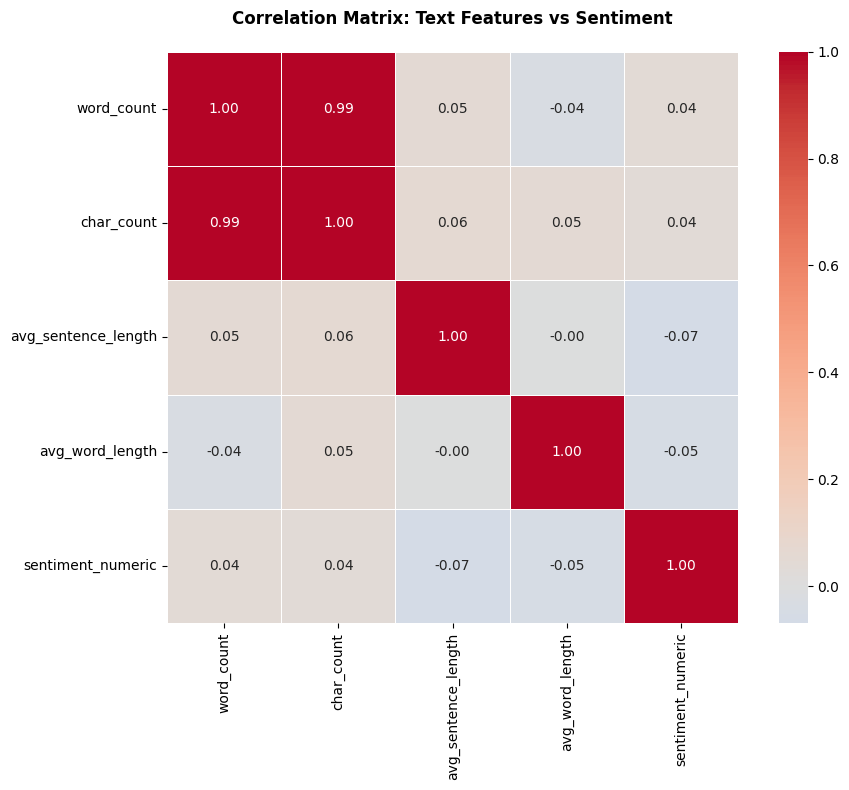

Correlation Matrix:
                     word_count  char_count  avg_sentence_length  \
word_count                1.000       0.993                0.053   
char_count                0.993       1.000                0.057   
avg_sentence_length       0.053       0.057                1.000   
avg_word_length          -0.035       0.050               -0.002   
sentiment_numeric         0.042       0.035               -0.069   

                     avg_word_length  sentiment_numeric  
word_count                    -0.035              0.042  
char_count                     0.050              0.035  
avg_sentence_length           -0.002             -0.069  
avg_word_length                1.000             -0.045  
sentiment_numeric             -0.045              1.000  


In [20]:
# 7. CORRELATION ANALYSIS
print("\n📈 7. CORRELATION ANALYSIS")
print("=" * 50)

# Create numerical representation for correlation
balanced_df['sentiment_numeric'] = balanced_df['sentiment'].map({'negative': -1, 'neutral': 0, 'positive': 1})

# Calculate correlations
correlation_matrix = balanced_df[['word_count', 'char_count', 'avg_sentence_length', 'avg_word_length', 'sentiment_numeric']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, fmt='.2f')
plt.title('Correlation Matrix: Text Features vs Sentiment', fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("Correlation Matrix:")
print(correlation_matrix.round(3))




📏 9. TEXT LENGTH COMPARISON


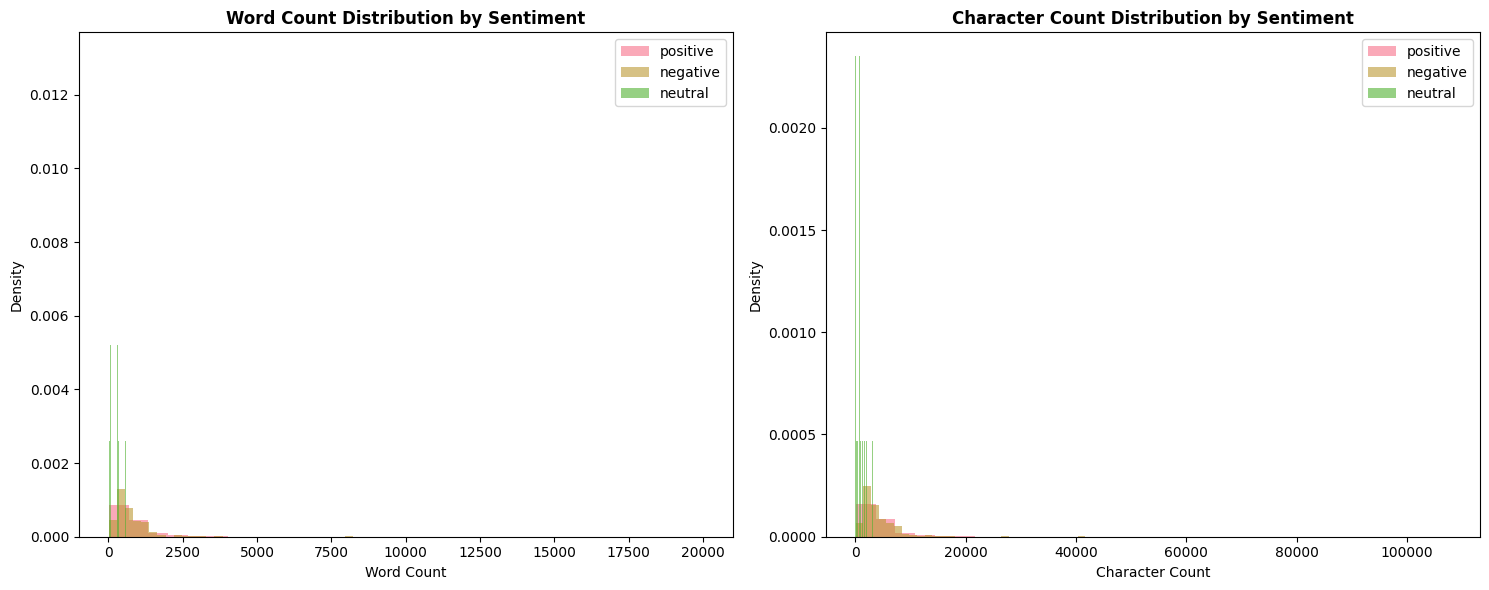

In [21]:
# 9. TEXT LENGTH DISTRIBUTION COMPARISON
print("\n📏 9. TEXT LENGTH COMPARISON")
print("=" * 50)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Word count distribution
for sentiment in balanced_df['sentiment'].unique():
    data = balanced_df[balanced_df['sentiment'] == sentiment]['word_count']
    ax1.hist(data, bins=30, alpha=0.6, label=sentiment, density=True)

ax1.set_xlabel('Word Count')
ax1.set_ylabel('Density')
ax1.set_title('Word Count Distribution by Sentiment', fontweight='bold')
ax1.legend()

# Character count distribution
for sentiment in balanced_df['sentiment'].unique():
    data = balanced_df[balanced_df['sentiment'] == sentiment]['char_count']
    ax2.hist(data, bins=30, alpha=0.6, label=sentiment, density=True)

ax2.set_xlabel('Character Count')
ax2.set_ylabel('Density')
ax2.set_title('Character Count Distribution by Sentiment', fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()



In [22]:
# Save the enhanced balanced dataset with all new features
enhanced_balanced_path = '/kaggle/working/enhanced_balanced_sentiment_dataset.csv'
balanced_df.to_csv(enhanced_balanced_path, index=False)



In [23]:
# 11. SUMMARY STATISTICS
print("\n📋 11. SUMMARY STATISTICS")
print("=" * 50)

print("Dataset Summary:")
print(f"Total samples: {len(balanced_df):,}")
print(f"Positive samples: {len(balanced_df[balanced_df['sentiment'] == 'positive']):,}")
print(f"Negative samples: {len(balanced_df[balanced_df['sentiment'] == 'negative']):,}")
print(f"Neutral samples: {len(balanced_df[balanced_df['sentiment'] == 'neutral']):,}")

print("\nText Statistics:")
print(f"Average word count: {balanced_df['word_count'].mean():.1f}")
print(f"Average character count: {balanced_df['char_count'].mean():.1f}")
print(f"Average sentence length: {balanced_df['avg_sentence_length'].mean():.1f} words")

print("\nSentiment-specific Text Lengths:")
for sentiment in balanced_df['sentiment'].unique():
    avg_words = balanced_df[balanced_df['sentiment'] == sentiment]['word_count'].mean()
    print(f"  {sentiment}: {avg_words:.1f} words on average")



📋 11. SUMMARY STATISTICS
Dataset Summary:
Total samples: 190,968
Positive samples: 95,474
Negative samples: 95,474
Neutral samples: 20

Text Statistics:
Average word count: 758.7
Average character count: 4166.0
Average sentence length: 9.3 words

Sentiment-specific Text Lengths:
  positive: 786.3 words on average
  negative: 731.2 words on average
  neutral: 123.8 words on average


# Here is the Feature Engineering : Converting Text to Numerical Features

In [24]:
# ============================================
# CELL 1: IMPORT LIBRARIES AND SETUP
# ============================================
# This cell imports all necessary libraries for the ML pipeline
# Sets up warnings and prepares the environment for machine learning

import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

print("🚀 COMPREHENSIVE SENTIMENT ANALYSIS ML PIPELINE")
print("=" * 60)

🚀 COMPREHENSIVE SENTIMENT ANALYSIS ML PIPELINE


In [25]:
# ============================================
# CELL 2: LOAD AND EXPLORE DATASET
# ============================================
# This cell loads the enhanced balanced dataset created in previous cells
# Provides overview of data shape, columns, and sentiment distribution
# Checks for missing values and data quality

print("\n📊 1. LOADING ENHANCED DATASET")
print("-" * 40)

# Load the enhanced balanced dataset
df = pd.read_csv('/kaggle/working/enhanced_balanced_sentiment_dataset.csv')

print(f"Dataset Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nSentiment Distribution:")
print(df['sentiment'].value_counts())
print(f"\nMissing Values:\n{df.isnull().sum()}")

# Display sample data
print("\nSample Data:")
print(df.head(3))


📊 1. LOADING ENHANCED DATASET
----------------------------------------
Dataset Shape: (190968, 9)
Columns: ['ID', 'cleaned_transcript', 'sentiment', 'word_count', 'char_count', 'sentence_count', 'avg_sentence_length', 'avg_word_length', 'sentiment_numeric']

Sentiment Distribution:
sentiment
positive    95474
negative    95474
neutral        20
Name: count, dtype: int64

Missing Values:
ID                     0
cleaned_transcript     0
sentiment              0
word_count             0
char_count             0
sentence_count         0
avg_sentence_length    0
avg_word_length        0
sentiment_numeric      0
dtype: int64

Sample Data:
                                                  ID  \
0  /kaggle/input/arxive-ninety-thousand/medicare_...   
1  /kaggle/input/arxive-ninety-thousand/medicare_...   
2  /kaggle/input/arxive-ninety-thousand/automotiv...   

                                  cleaned_transcript sentiment  word_count  \
0  Thank you for calling ORGANIZATION ORGANIZATIO...  

In [26]:
# ============================================
# CELL 3: PREPARE DATA FOR MODELING
# ============================================
# This cell separates text data and numerical features
# Prepares the target variable (sentiment labels)
# Shows class distribution and data overview

print("\n🎯 2. PREPARING DATA FOR MODELING")
print("-" * 40)

# Use cleaned transcript and additional features
X_text = df['cleaned_transcript']
y = df['sentiment']

# Additional numerical features
additional_features = df[['word_count', 'char_count', 'avg_sentence_length', 'avg_word_length']].values

print(f"Text samples: {len(X_text)}")
print(f"Additional features shape: {additional_features.shape}")
print(f"\nClass distribution:")
print(y.value_counts())

# Show sample text
print(f"\nSample text (first 200 chars):")
print(X_text.iloc[0][:200] + "...")


🎯 2. PREPARING DATA FOR MODELING
----------------------------------------
Text samples: 190968
Additional features shape: (190968, 4)

Class distribution:
sentiment
positive    95474
negative    95474
neutral        20
Name: count, dtype: int64

Sample text (first 200 chars):
Thank you for calling ORGANIZATION ORGANIZATION. If you are a new patient, please press PHONENUMBER. If you are an existing state, this call may be recorded for quality control. ORGANIZATION, ORGANIZA...


In [27]:
# ============================================
# CELL 4: ADVANCED FEATURE ENGINEERING (FIXED)
# ============================================
# This cell converts text to numerical features using TF-IDF
# Combines text features with existing numerical features
# Creates a comprehensive feature matrix for machine learning
# MEMORY-OPTIMIZED: Uses sparse matrices to prevent kernel death

print("\n🔧 3. ADVANCED FEATURE ENGINEERING")
print("-" * 40)

# TF-IDF Vectorization with optimized parameters
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,        # Reduced to prevent overfitting
    min_df=3,                 # Increased to filter rare words
    max_df=0.8,               # Increased to filter common words
    ngram_range=(1, 2),       # Only unigrams and bigrams
    strip_accents='unicode',
    lowercase=True,
    sublinear_tf=True,
    stop_words='english'
)

# Fit and transform text data
X_tfidf = tfidf_vectorizer.fit_transform(X_text)
print(f"✅ TF-IDF Matrix Shape: {X_tfidf.shape}")
print(f"📊 Sparsity: {(1.0 - X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1])) * 100:.2f}%")

# CRITICAL FIX: Keep everything SPARSE to save memory!
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix
import gc

# Feature scaling for linear models
scaler = StandardScaler()
additional_features_scaled = scaler.fit_transform(additional_features)

# Convert additional features to sparse format
additional_features_sparse = csr_matrix(additional_features_scaled)

# Combine TF-IDF features with scaled additional features (KEEP SPARSE!)
X_combined = hstack([X_tfidf, additional_features_sparse])
print(f"🔗 Combined feature matrix shape: {X_combined.shape}")
print(f"💾 Memory (sparse): {X_combined.data.nbytes / 1024**2:.2f} MB")

# For Naive Bayes: Keep TF-IDF sparse (MultinomialNB works with sparse!)
X_nb = X_tfidf
print(f"🔗 Naive Bayes feature matrix (sparse): {X_nb.shape}")

# Clear intermediate variables to free memory
del additional_features_scaled, additional_features_sparse
gc.collect()

# Show sample features
feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"\n🔤 Sample TF-IDF features: {list(feature_names[:20])}")


🔧 3. ADVANCED FEATURE ENGINEERING
----------------------------------------
✅ TF-IDF Matrix Shape: (190968, 5000)
📊 Sparsity: 96.23%
🔗 Combined feature matrix shape: (190968, 5004)
💾 Memory (sparse): 280.69 MB
🔗 Naive Bayes feature matrix (sparse): (190968, 5000)

🔤 Sample TF-IDF features: ['000', '000 miles', '10', '100', '12', '12 000', '12 coverage', '15', '18', '20', '25', '30', '300', '40', '50', '500', '600', 'abandoned', 'abandoned wildlife', 'able']


In [28]:
# ============================================
# CELL 5: LABEL ENCODING
# ============================================
# This cell converts text sentiment labels to numerical format
# Required for machine learning algorithms
# Shows the mapping between text and numerical labels

print("\n🏷️ 4. LABEL ENCODING")
print("-" * 40)

# Encode sentiment labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"Label mapping: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}")
print(f"Encoded labels shape: {y_encoded.shape}")
print(f"Original labels: {label_encoder.classes_}")
print(f"Encoded labels: {np.unique(y_encoded)}")


🏷️ 4. LABEL ENCODING
----------------------------------------
Label mapping: {'negative': 0, 'neutral': 1, 'positive': 2}
Encoded labels shape: (190968,)
Original labels: ['negative' 'neutral' 'positive']
Encoded labels: [0 1 2]


In [29]:
# ============================================
# CELL 6: TRAIN-TEST SPLIT
# ============================================
# This cell splits data into training and testing sets
# Maintains class distribution in both sets (stratified split)
# Prepares data for model training and evaluation

print("\n✂️ 5. TRAIN-TEST SPLIT")
print("-" * 40)

X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y_encoded, 
    test_size=0.2, 
    random_state=42,
    stratify=y_encoded
)

print(f"Training samples: {X_train.shape[0]} ({X_train.shape[0]/X_combined.shape[0]*100:.1f}%)")
print(f"Testing samples: {X_test.shape[0]} ({X_test.shape[0]/X_combined.shape[0]*100:.1f}%)")
print(f"\nTraining set distribution: {np.bincount(y_train)}")
print(f"Testing set distribution: {np.bincount(y_test)}")

# Verify stratified split
print(f"\nTraining class proportions:")
for i, class_name in enumerate(label_encoder.classes_):
    prop = np.bincount(y_train)[i] / len(y_train) * 100
    print(f"  {class_name}: {prop:.1f}%")


✂️ 5. TRAIN-TEST SPLIT
----------------------------------------
Training samples: 152774 (80.0%)
Testing samples: 38194 (20.0%)

Training set distribution: [76379    16 76379]
Testing set distribution: [19095     4 19095]

Training class proportions:
  negative: 50.0%
  neutral: 0.0%
  positive: 50.0%


In [30]:
# ============================================
# CELL 7: TRAIN LOGISTIC REGRESSION MODEL (FIXED)
# ============================================
# This cell trains a Logistic Regression model
# Performs cross-validation for robust evaluation
# Calculates multiple performance metrics

print("\n📈 MODEL 1: LOGISTIC REGRESSION")
print("-" * 30)

lr_model = LogisticRegression(
    max_iter=5000,              # Increased iterations
    random_state=42,
    class_weight='balanced',
    solver='liblinear',         # Better for small datasets
    C=0.1,                      # Stronger regularization
    penalty='l2'
)

print("Training Logistic Regression...")
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# Cross-validation
lr_cv_scores = cross_val_score(lr_model, X_train, y_train, cv=5, scoring='f1_weighted')

# Evaluate
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred, average='weighted')
lr_precision = precision_score(y_test, lr_pred, average='weighted')
lr_recall = recall_score(y_test, lr_pred, average='weighted')

print(f"✅ Accuracy: {lr_accuracy:.4f}")
print(f"📊 F1-Score: {lr_f1:.4f}")
print(f"🎯 Precision: {lr_precision:.4f}")
print(f"🔍 Recall: {lr_recall:.4f}")
print(f"🔄 CV F1-Score: {lr_cv_scores.mean():.4f} (+/- {lr_cv_scores.std() * 2:.4f})")

# Store results
results = {}
results['Logistic Regression'] = {
    'accuracy': lr_accuracy,
    'f1_score': lr_f1,
    'precision': lr_precision,
    'recall': lr_recall,
    'cv_f1': lr_cv_scores.mean(),
    'predictions': lr_pred,
    'model': lr_model
}


📈 MODEL 1: LOGISTIC REGRESSION
------------------------------
Training Logistic Regression...
✅ Accuracy: 0.9846
📊 F1-Score: 0.9847
🎯 Precision: 0.9852
🔍 Recall: 0.9846
🔄 CV F1-Score: 0.9832 (+/- 0.0009)


In [31]:
# ============================================
# CELL 8: TRAIN NAIVE BAYES MODEL (FIXED)
# ============================================
# This cell trains a Multinomial Naive Bayes model
# Good baseline model for text classification
# Fast training and often performs well on text data

print("\n📈 MODEL 2: NAIVE BAYES")
print("-" * 30)

nb_model = MultinomialNB(alpha=0.1)

print("Training Naive Bayes...")
# Create separate train-test split for Naive Bayes using only TF-IDF features
from sklearn.model_selection import train_test_split

X_nb_train, X_nb_test, y_nb_train, y_nb_test = train_test_split(
    X_nb, y_encoded, 
    test_size=0.2, 
    random_state=42,
    stratify=y_encoded
)

# Train on TF-IDF features only (no negative values)
nb_model.fit(X_nb_train, y_nb_train)
nb_pred = nb_model.predict(X_nb_test)

# Cross-validation
nb_cv_scores = cross_val_score(nb_model, X_nb_train, y_nb_train, cv=5, scoring='f1_weighted')

# Evaluate using the same test set
nb_accuracy = accuracy_score(y_nb_test, nb_pred)
nb_f1 = f1_score(y_nb_test, nb_pred, average='weighted')
nb_precision = precision_score(y_nb_test, nb_pred, average='weighted')
nb_recall = recall_score(y_nb_test, nb_pred, average='weighted')

print(f"✅ Accuracy: {nb_accuracy:.4f}")
print(f"📊 F1-Score: {nb_f1:.4f}")
print(f"🎯 Precision: {nb_precision:.4f}")
print(f"🔍 Recall: {nb_recall:.4f}")
print(f"🔄 CV F1-Score: {nb_cv_scores.mean():.4f} (+/- {nb_cv_scores.std() * 2:.4f})")

results['Naive Bayes'] = {
    'accuracy': nb_accuracy,
    'f1_score': nb_f1,
    'precision': nb_precision,
    'recall': nb_recall,
    'cv_f1': nb_cv_scores.mean(),
    'predictions': nb_pred,
    'model': nb_model
}


📈 MODEL 2: NAIVE BAYES
------------------------------
Training Naive Bayes...
✅ Accuracy: 0.8947
📊 F1-Score: 0.8961
🎯 Precision: 0.8990
🔍 Recall: 0.8947
🔄 CV F1-Score: 0.8976 (+/- 0.0052)


In [32]:
# ============================================
# CELL 9: TRAIN RANDOM FOREST MODEL
# ============================================
# This cell trains a Random Forest ensemble model
# Provides feature importance analysis
# Often performs well on mixed feature types

print("\n📈 MODEL 3: RANDOM FOREST")
print("-" * 30)

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=25,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

print("Training Random Forest...")
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# Cross-validation
rf_cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='f1_weighted')

# Evaluate
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred, average='weighted')
rf_precision = precision_score(y_test, rf_pred, average='weighted')
rf_recall = recall_score(y_test, rf_pred, average='weighted')

print(f"✅ Accuracy: {rf_accuracy:.4f}")
print(f"📊 F1-Score: {rf_f1:.4f}")
print(f"🎯 Precision: {rf_precision:.4f}")
print(f"🔍 Recall: {rf_recall:.4f}")
print(f"🔄 CV F1-Score: {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std() * 2:.4f})")

results['Random Forest'] = {
    'accuracy': rf_accuracy,
    'f1_score': rf_f1,
    'precision': rf_precision,
    'recall': rf_recall,
    'cv_f1': rf_cv_scores.mean(),
    'predictions': rf_pred,
    'model': rf_model
}


📈 MODEL 3: RANDOM FOREST
------------------------------
Training Random Forest...
✅ Accuracy: 0.9987
📊 F1-Score: 0.9992
🎯 Precision: 0.9998
🔍 Recall: 0.9987
🔄 CV F1-Score: 0.9992 (+/- 0.0002)


In [33]:
# ============================================
# CELL 10: TRAIN SVM MODEL
# ============================================
print("\n📈 MODEL 4: SUPPORT VECTOR MACHINE")
print("-" * 30)

# Use LinearSVC for better sparse matrix handling
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    max_iter=5000,
    C=1.0,
    class_weight='balanced',
    random_state=42,
    dual=False  # Better for sparse matrices
)

print("Training SVM...")
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)

# Cross-validation with error handling
try:
    svm_cv_scores = cross_val_score(svm_model, X_train, y_train, cv=5, scoring='f1_weighted')
    # Filter out invalid CV scores
    svm_cv_scores_clean = svm_cv_scores[np.isfinite(svm_cv_scores)]
    if len(svm_cv_scores_clean) > 0:
        svm_cv_mean = svm_cv_scores_clean.mean()
        svm_cv_std = svm_cv_scores_clean.std()
    else:
        svm_cv_mean = 0.0
        svm_cv_std = 0.0
        print("⚠️ Warning: All CV scores were invalid, using default 0.0")
except Exception as e:
    print(f"⚠️ CV failed: {e}, using default")
    svm_cv_mean = 0.0
    svm_cv_std = 0.0
    svm_cv_scores = np.array([0.0])

# Helper function to ensure metrics are valid
def safe_metric(value, default=0.0):
    """Ensure metric is a valid finite number"""
    if pd.isna(value) or not np.isfinite(value):
        return default
    return float(value)

# Calculate and validate metrics
svm_accuracy = safe_metric(accuracy_score(y_test, svm_pred))
svm_f1 = safe_metric(f1_score(y_test, svm_pred, average='weighted'))
svm_precision = safe_metric(precision_score(y_test, svm_pred, average='weighted'))
svm_recall = safe_metric(recall_score(y_test, svm_pred, average='weighted'))

print(f"✅ Accuracy: {svm_accuracy:.4f}")
print(f"📊 F1-Score: {svm_f1:.4f}")
print(f"🎯 Precision: {svm_precision:.4f}")
print(f"🔍 Recall: {svm_recall:.4f}")
print(f"🔄 CV F1-Score: {svm_cv_mean:.4f} (+/- {svm_cv_std * 2:.4f})")

results['SVM'] = {
    'accuracy': svm_accuracy,
    'f1_score': svm_f1,
    'precision': svm_precision,
    'recall': svm_recall,
    'cv_f1': svm_cv_mean,
    'predictions': svm_pred,
    'model': svm_model
}


📈 MODEL 4: SUPPORT VECTOR MACHINE
------------------------------
Training SVM...
✅ Accuracy: 0.9979
📊 F1-Score: 0.9979
🎯 Precision: 0.9979
🔍 Recall: 0.9979
🔄 CV F1-Score: 0.9976 (+/- 0.0002)


In [34]:
# ============================================
# CELL 11: MODEL COMPARISON AND ANALYSIS
# ============================================
print("\n📊 6. MODEL COMPARISON & ANALYSIS")
print("-" * 40)

# Create comprehensive comparison dataframe
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results.keys()],
    'F1-Score': [results[m]['f1_score'] for m in results.keys()],
    'Precision': [results[m]['precision'] for m in results.keys()],
    'Recall': [results[m]['recall'] for m in results.keys()],
    'CV_F1-Score': [results[m]['cv_f1'] for m in results.keys()]
})

# FIX: Clean comparison_df to remove NaN and inf values
for col in comparison_df.select_dtypes(include=[np.number]).columns:
    comparison_df[col] = comparison_df[col].replace([np.inf, -np.inf], np.nan)
    comparison_df[col] = comparison_df[col].fillna(0)
    # Ensure all values are finite and in valid range [0, 1]
    comparison_df[col] = np.clip(comparison_df[col], 0, 1)

print("📋 COMPREHENSIVE MODEL COMPARISON:")
print(comparison_df.round(4))

# Identify best model based on F1-score (handle NaN values)
f1_scores = comparison_df['F1-Score'].values
cv_f1_scores = comparison_df['CV_F1-Score'].values

best_model_name = comparison_df.loc[f1_scores.argmax(), 'Model']
best_cv_model = comparison_df.loc[cv_f1_scores.argmax(), 'Model']

print(f"\n🏆 Best Model (Test F1): {best_model_name} (F1: {f1_scores.max():.4f})")
print(f"🏆 Best Model (CV F1): {best_cv_model} (CV F1: {cv_f1_scores.max():.4f})")

# Show detailed classification report for best model
print(f"\n📋 DETAILED CLASSIFICATION REPORT - {best_model_name}:")
print(classification_report(y_test, results[best_model_name]['predictions'], 
                           target_names=label_encoder.classes_))


📊 6. MODEL COMPARISON & ANALYSIS
----------------------------------------
📋 COMPREHENSIVE MODEL COMPARISON:
                 Model  Accuracy  F1-Score  Precision  Recall  CV_F1-Score
0  Logistic Regression    0.9846    0.9847     0.9852  0.9846       0.9832
1          Naive Bayes    0.8947    0.8961     0.8990  0.8947       0.8976
2        Random Forest    0.9987    0.9992     0.9998  0.9987       0.9992
3                  SVM    0.9979    0.9979     0.9979  0.9979       0.9976

🏆 Best Model (Test F1): Random Forest (F1: 0.9992)
🏆 Best Model (CV F1): Random Forest (CV F1: 0.9992)

📋 DETAILED CLASSIFICATION REPORT - Random Forest:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00     19095
     neutral       0.04      0.50      0.08         4
    positive       1.00      1.00      1.00     19095

    accuracy                           1.00     38194
   macro avg       0.68      0.83      0.69     38194
weighted avg       1.00      1.00  


📈 7. PERFORMANCE VISUALIZATION
----------------------------------------


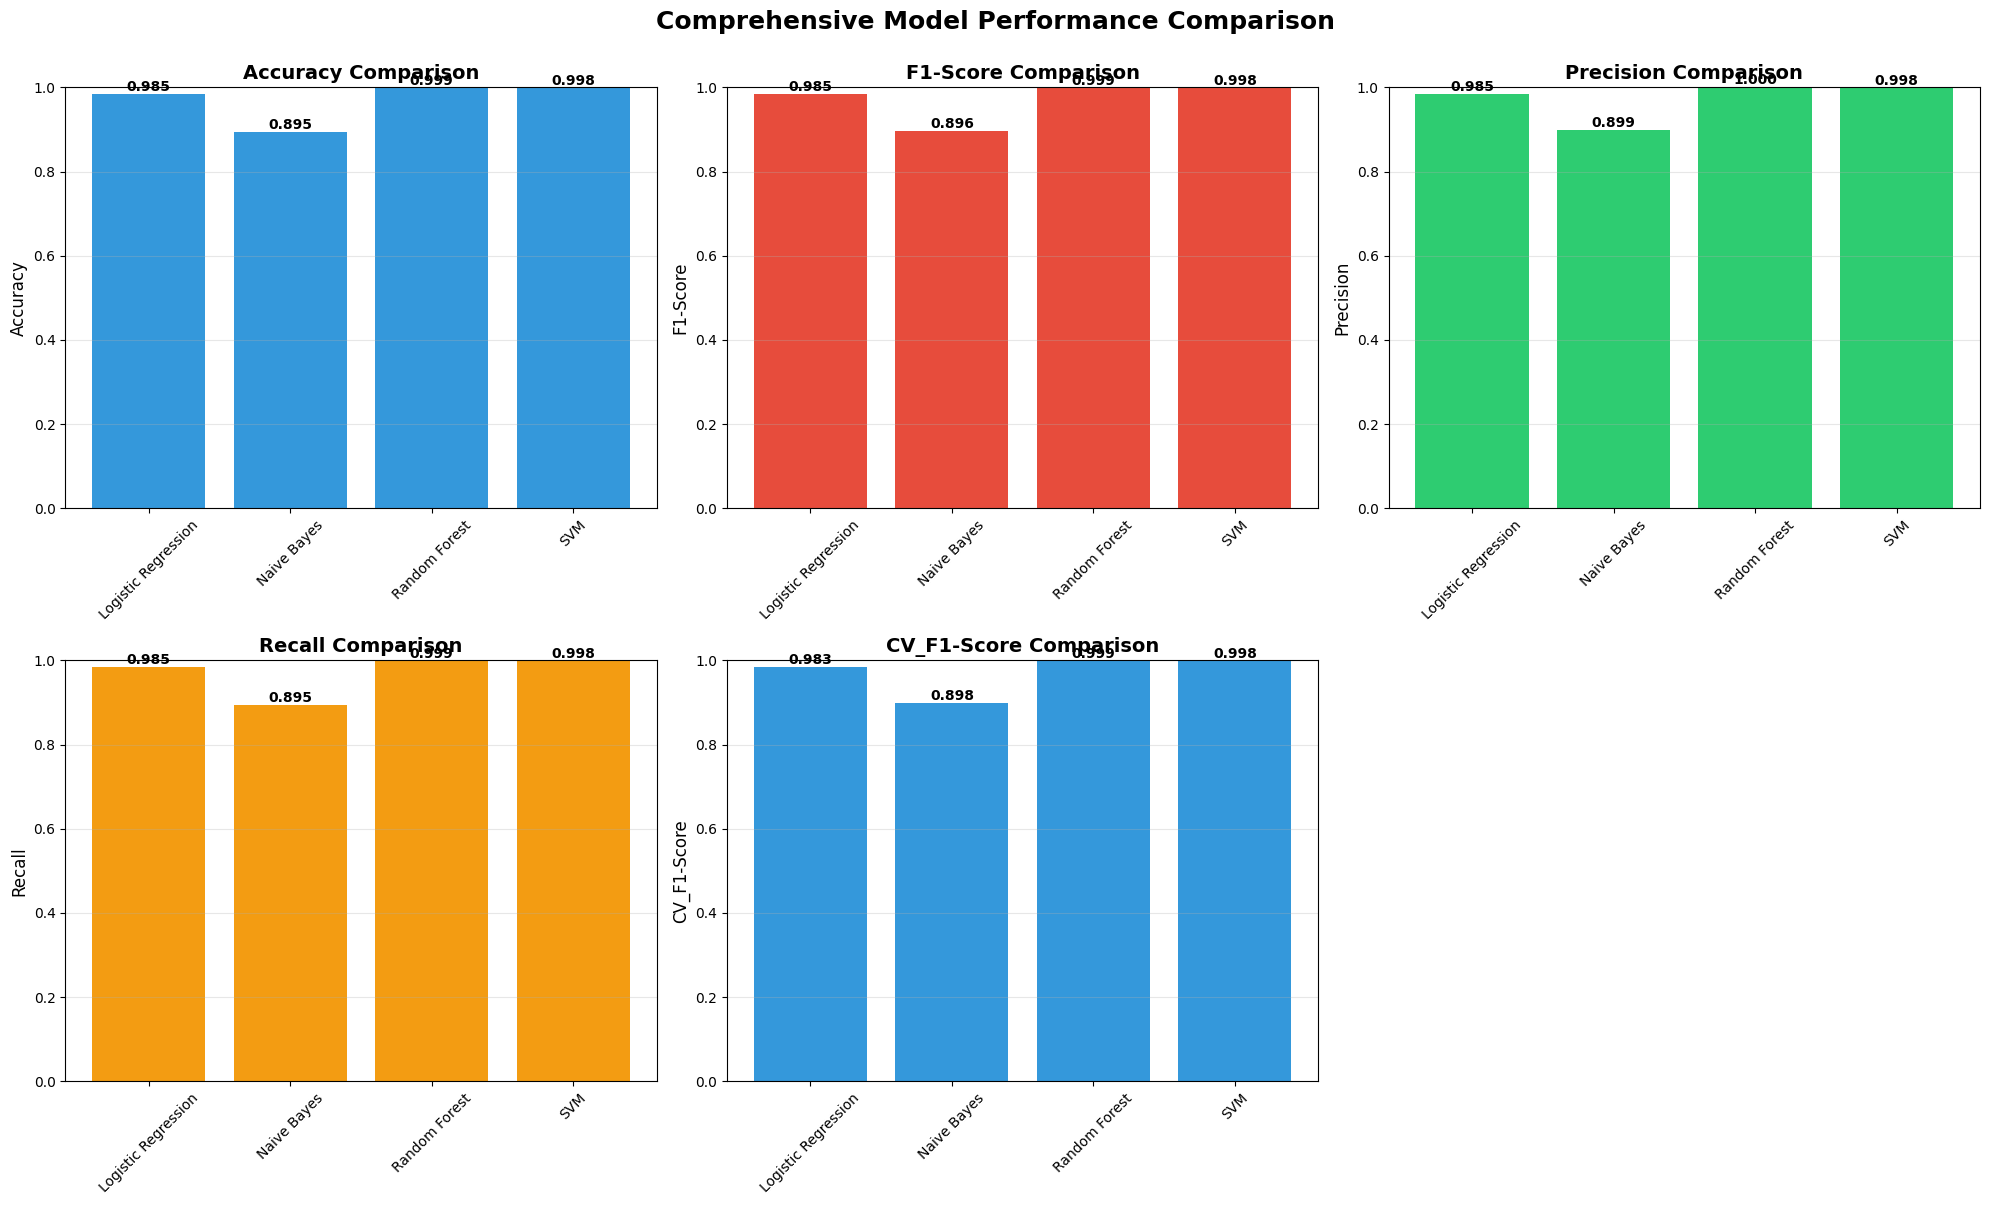

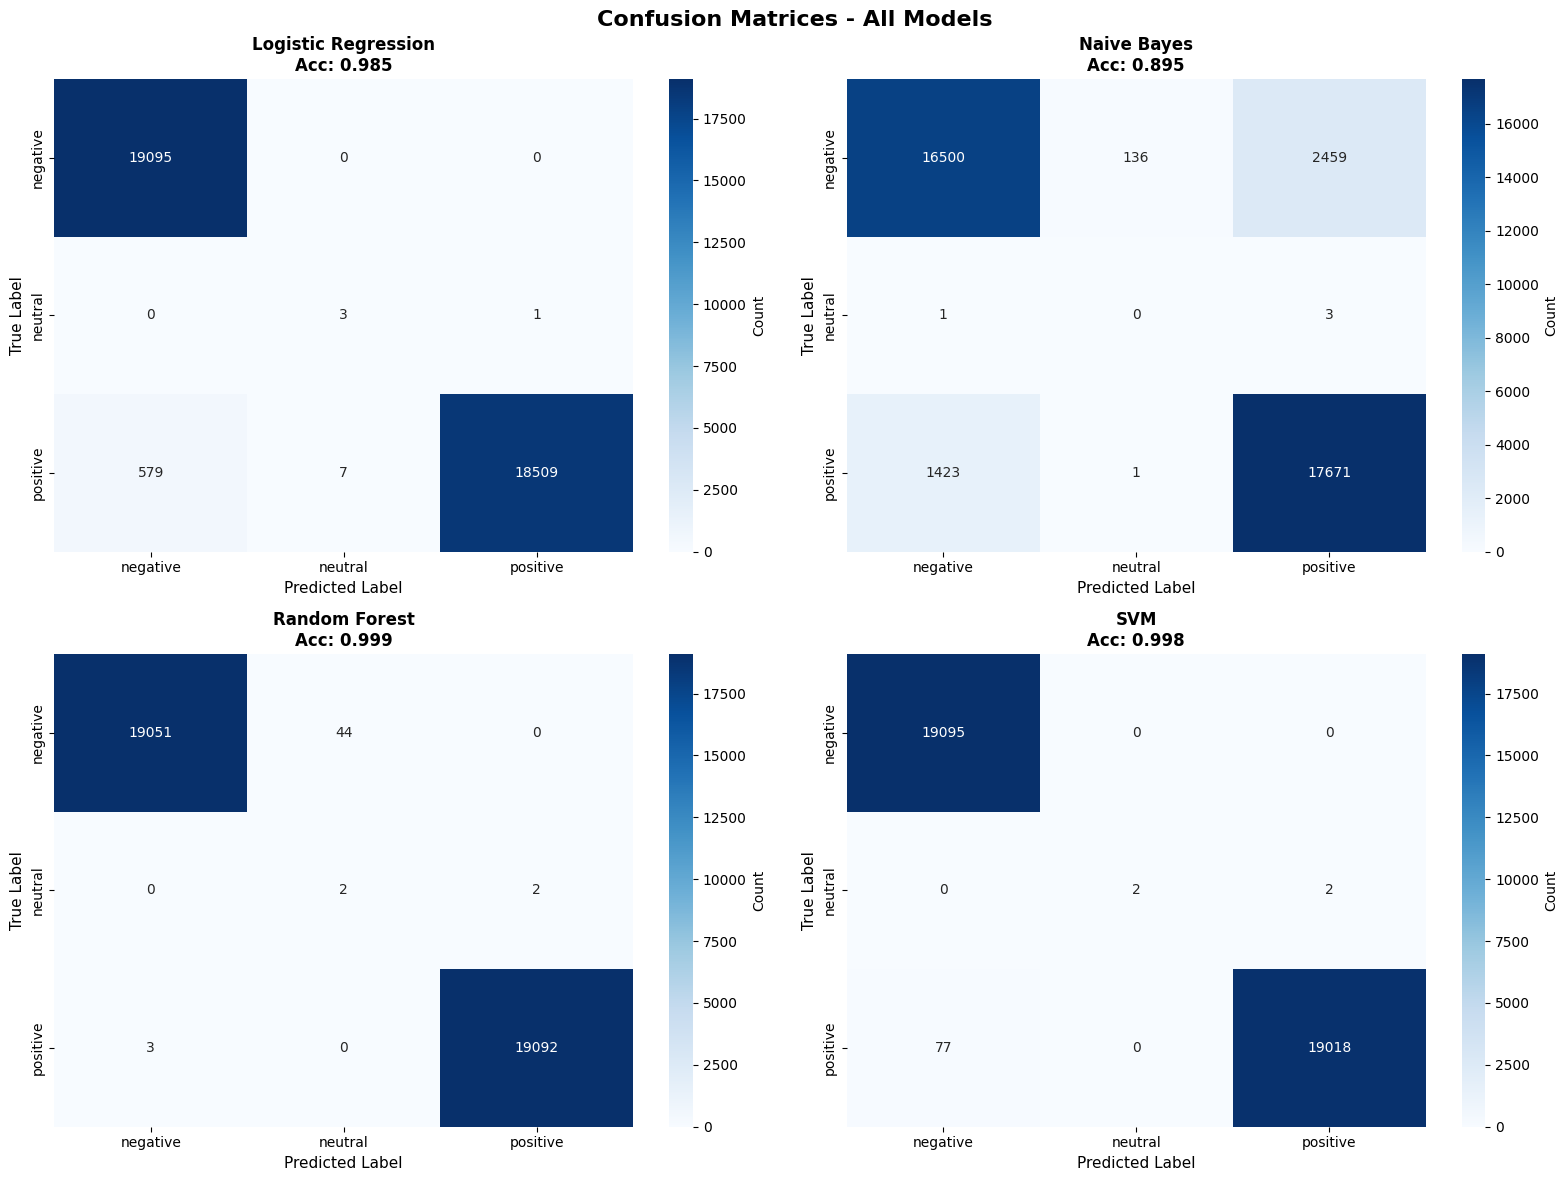

In [35]:
# ============================================
# CELL 12: PERFORMANCE VISUALIZATION
# ============================================
print("\n📈 7. PERFORMANCE VISUALIZATION")
print("-" * 40)

# FIX: Clean data before plotting (safety net)
comparison_df_clean = comparison_df.copy()
for col in comparison_df_clean.select_dtypes(include=[np.number]).columns:
    comparison_df_clean[col] = comparison_df_clean[col].replace([np.inf, -np.inf], np.nan)
    comparison_df_clean[col] = comparison_df_clean[col].fillna(0)
    comparison_df_clean[col] = np.clip(comparison_df_clean[col], 0, 1)

# Model Performance Comparison
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Comprehensive Model Performance Comparison', fontsize=18, fontweight='bold', y=1.00)

metrics = ['Accuracy', 'F1-Score', 'Precision', 'Recall', 'CV_F1-Score']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 3, idx % 3]
    metric_values = comparison_df_clean[metric].values
    bars = ax.bar(comparison_df_clean['Model'], metric_values, color=colors[idx % len(colors)])
    ax.set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    ax.set_ylabel(metric, fontsize=12)
    ax.set_ylim([0, 1])
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        if np.isfinite(height):
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

# Remove empty subplot
axes[1, 2].remove()
plt.tight_layout()
plt.show()

# Confusion Matrices
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Confusion Matrices - All Models', fontsize=16, fontweight='bold')

model_names = list(results.keys())
for idx, model_name in enumerate(model_names):
    ax = axes[idx // 2, idx % 2]
    cm = confusion_matrix(y_test, results[model_name]['predictions'])
    cm = np.nan_to_num(cm, nan=0, posinf=0, neginf=0)  # Clean confusion matrix
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=label_encoder.classes_, 
                yticklabels=label_encoder.classes_,
                ax=ax,
                cbar_kws={'label': 'Count'})
    
    acc_value = results[model_name]["accuracy"]
    if not np.isfinite(acc_value):
        acc_value = 0.0
    ax.set_title(f'{model_name}\nAcc: {acc_value:.3f}', 
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=11)
    ax.set_xlabel('Predicted Label', fontsize=11)

plt.tight_layout()
plt.show()


🎯 8. FEATURE IMPORTANCE ANALYSIS
----------------------------------------
TOP 25 IMPORTANT FEATURES (Random Forest)
----------------------------------------
 1. injury injury                  : 0.036902
 2. injury                         : 0.032927
 3. char_count                     : 0.021940
 4. word_count                     : 0.020289
 5. personname personname          : 0.012432
 6. good                           : 0.012075
 7. avg_word_length                : 0.011962
 8. avg_sentence_length            : 0.010952
 9. want                           : 0.010482
10. calling                        : 0.008863
11. duration                       : 0.008663
12. let                            : 0.008340
13. organization personname        : 0.008187
14. help                           : 0.007869
15. need                           : 0.007658
16. duration duration              : 0.007471
17. medicalprocess medicalprocess  : 0.007390
18. make                           : 0.006888
19. going     

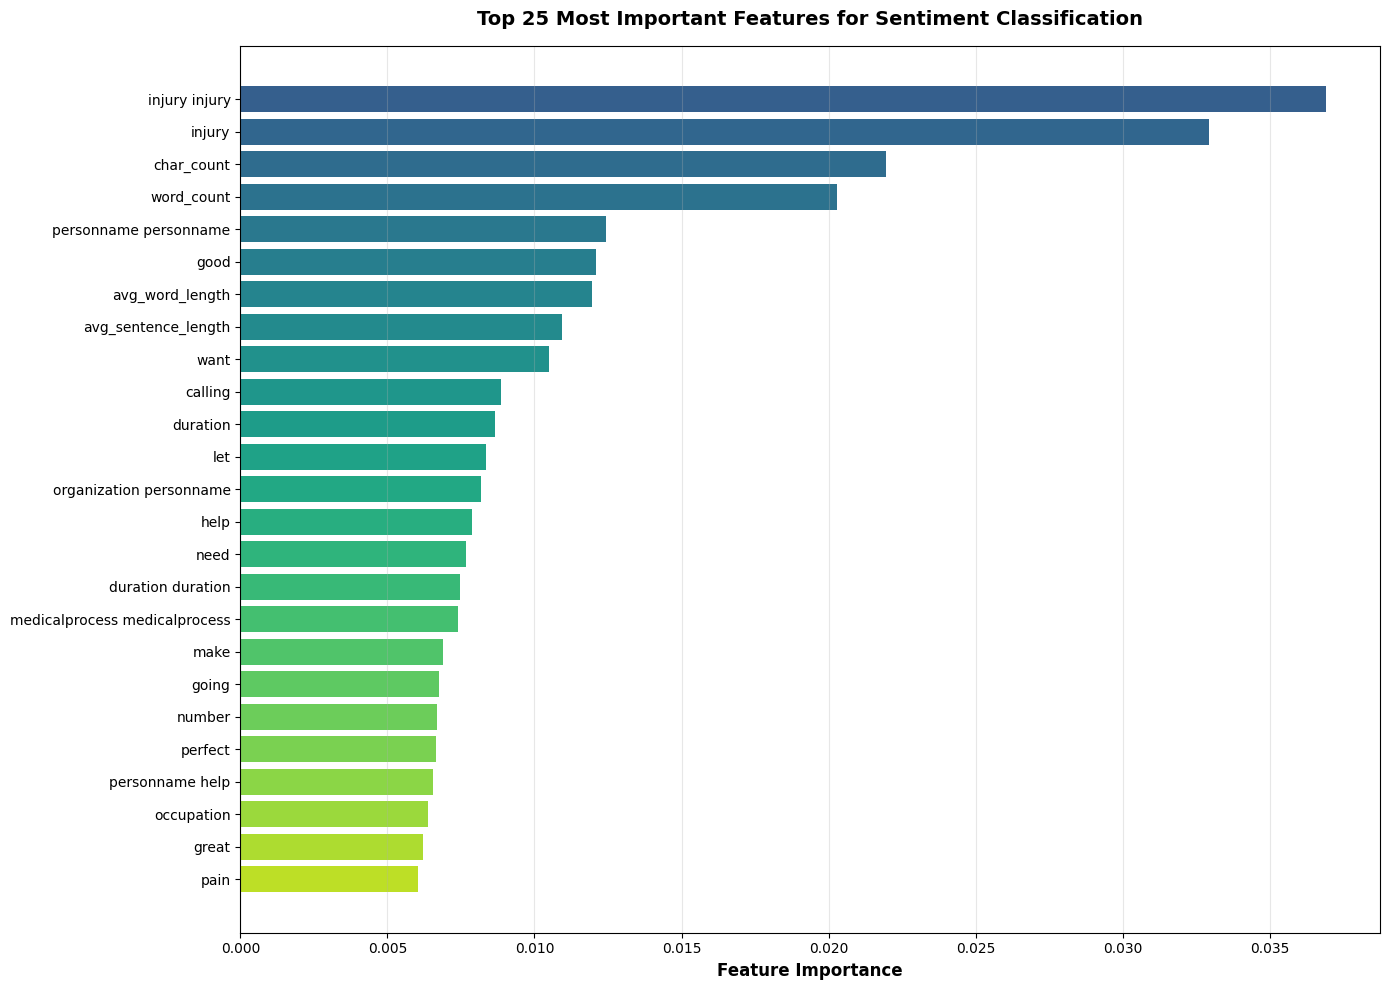

In [36]:
# ============================================
# CELL 13: FEATURE IMPORTANCE ANALYSIS
# ============================================
# This cell analyzes feature importance from Random Forest
# Shows which words/features are most important for classification
# Helps understand what the model is learning

print("\n🎯 8. FEATURE IMPORTANCE ANALYSIS")
print("-" * 40)

if 'Random Forest' in results:
    print("TOP 25 IMPORTANT FEATURES (Random Forest)")
    print("-" * 40)
    
    # Get feature importances
    importances = rf_model.feature_importances_
    indices = np.argsort(importances)[::-1][:25]
    
    # Get feature names
    feature_names = tfidf_vectorizer.get_feature_names_out()
    all_feature_names = list(feature_names) + ['word_count', 'char_count', 'avg_sentence_length', 'avg_word_length']
    
    top_features = [(all_feature_names[i], importances[i]) for i in indices]
    
    # Display
    for i, (feature, importance) in enumerate(top_features, 1):
        print(f"{i:2d}. {feature:30s} : {importance:.6f}")
    
    # Plot
    plt.figure(figsize=(14, 10))
    colors_gradient = plt.cm.viridis(np.linspace(0.3, 0.9, 25))
    plt.barh(range(25), [importances[i] for i in indices], color=colors_gradient)
    plt.yticks(range(25), [all_feature_names[i] for i in indices], fontsize=10)
    plt.xlabel('Feature Importance', fontsize=12, fontweight='bold')
    plt.title('Top 25 Most Important Features for Sentiment Classification', 
              fontsize=14, fontweight='bold', pad=15)
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()


📈 9. CLASS-WISE PERFORMANCE ANALYSIS
----------------------------------------

Best Model: Random Forest
      Class  Precision  Recall  F1-Score  Support
0  negative     0.9998  0.9977    0.9988    19095
1   neutral     0.0435  0.5000    0.0800        4
2  positive     0.9999  0.9998    0.9999    19095


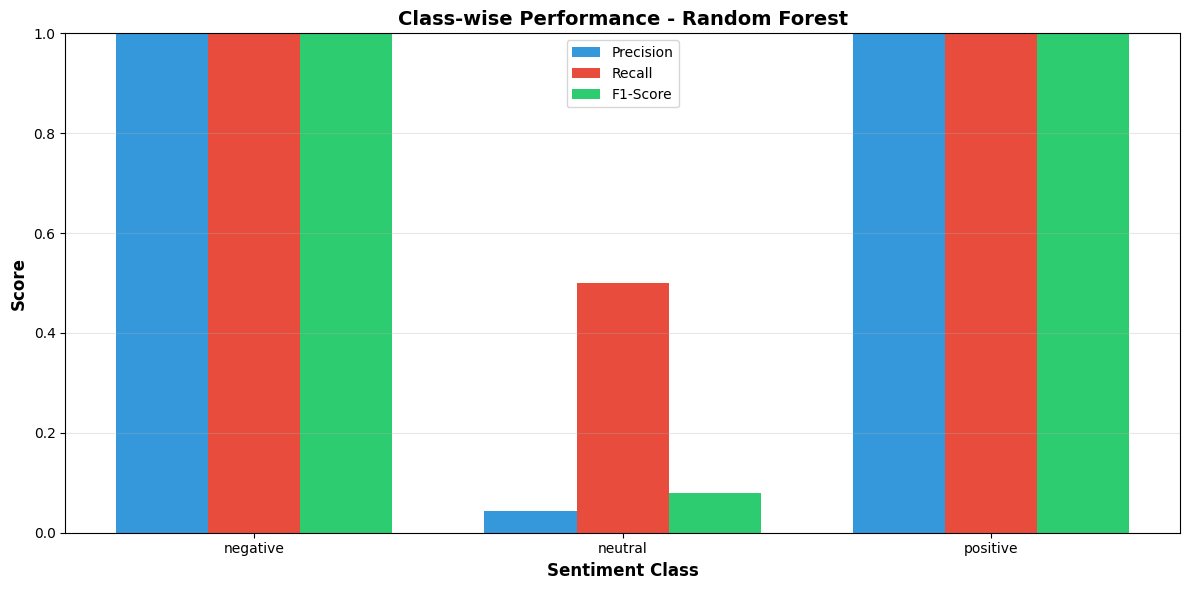

In [37]:
# ============================================
# CELL 14: CLASS-WISE PERFORMANCE ANALYSIS
# ============================================
# This cell analyzes performance for each sentiment class
# Shows precision, recall, and F1-score for each class
# Helps identify which classes are harder to predict

print("\n📈 9. CLASS-WISE PERFORMANCE ANALYSIS")
print("-" * 40)

# Best model detailed analysis
best_pred = results[best_model_name]['predictions']

from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(y_test, best_pred)

class_performance = pd.DataFrame({
    'Class': label_encoder.classes_,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})

print(f"\nBest Model: {best_model_name}")
print(class_performance.round(4))

# Visualize class-wise performance
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(class_performance))
width = 0.25

bars1 = ax.bar(x - width, class_performance['Precision'], width, label='Precision', color='#3498db')
bars2 = ax.bar(x, class_performance['Recall'], width, label='Recall', color='#e74c3c')
bars3 = ax.bar(x + width, class_performance['F1-Score'], width, label='F1-Score', color='#2ecc71')

ax.set_xlabel('Sentiment Class', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title(f'Class-wise Performance - {best_model_name}', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(class_performance['Class'])
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

In [38]:
# ============================================
# CELL 15: SAVE RESULTS AND MODELS
# ============================================
# This cell saves all results, models, and preprocessed data
# Enables future use without retraining
# Creates persistence for production deployment

print("\n💾 10. SAVE RESULTS & MODELS")
print("-" * 40)

# Save comparison results
comparison_df.to_csv('/kaggle/working/comprehensive_model_comparison.csv', index=False)
print("✅ Model comparison saved to: comprehensive_model_comparison.csv")

# Save predictions for best model
predictions_df = pd.DataFrame({
    'true_label': label_encoder.inverse_transform(y_test),
    'predicted_label': label_encoder.inverse_transform(best_pred)
})
predictions_df.to_csv('/kaggle/working/best_model_predictions.csv', index=False)
print("✅ Predictions saved to: best_model_predictions.csv")

# Save preprocessed data
np.save('/kaggle/working/X_train.npy', X_train)
np.save('/kaggle/working/X_test.npy', X_test)
np.save('/kaggle/working/y_train.npy', y_train)
np.save('/kaggle/working/y_test.npy', y_test)
print("✅ Preprocessed data saved")

# Save vectorizer and label encoder
with open('/kaggle/working/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)

with open('/kaggle/working/label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

# Save best model
with open('/kaggle/working/best_model.pkl', 'wb') as f:
    pickle.dump(results[best_model_name]['model'], f)

print("✅ Vectorizer, label encoder, and best model saved")


💾 10. SAVE RESULTS & MODELS
----------------------------------------
✅ Model comparison saved to: comprehensive_model_comparison.csv
✅ Predictions saved to: best_model_predictions.csv
✅ Preprocessed data saved
✅ Vectorizer, label encoder, and best model saved


In [39]:
# ============================================
# CELL 16: FINAL SUMMARY AND RECOMMENDATIONS
# ============================================
# This cell provides a comprehensive summary of results
# Gives recommendations for next steps
# Lists all files created for future reference

print("\n" + "=" * 60)
print("🎉 COMPREHENSIVE ML PIPELINE COMPLETE!")
print("=" * 60)

print(f"\n✅ Best Model: {best_model_name}")
print(f"📊 Best Accuracy: {results[best_model_name]['accuracy']:.4f}")
print(f"🎯 Best F1-Score: {results[best_model_name]['f1_score']:.4f}")
print(f"🔄 Best CV F1-Score: {results[best_model_name]['cv_f1']:.4f}")

print(f"\n🔍 Key Findings:")
print(f"   - Tested {len(results)} different models")
print(f"   - Used {X_combined.shape[1]} total features ({X_tfidf.shape[1]} TF-IDF + {additional_features.shape[1]} additional)")
print(f"   - Evaluated on {len(y_test)} test samples")
print(f"   - Cross-validation performed for robust evaluation")

print(f"\n💡 Next Steps:")
print(f"   1. Try deep learning models (LSTM, BERT, RoBERTa)")
print(f"   2. Address neutral class imbalance (only 20 samples)")
print(f"   3. Perform hyperparameter tuning on best model")
print(f"   4. Add more feature engineering (POS tags, named entities)")
print(f"   5. Implement ensemble methods")
print(f"   6. Create prediction API for real-time inference")

print(f"\n📁 Files Created:")
print(f"   - comprehensive_model_comparison.csv")
print(f"   - best_model_predictions.csv")
print(f"   - X_train.npy, X_test.npy, y_train.npy, y_test.npy")
print(f"   - tfidf_vectorizer.pkl, label_encoder.pkl, best_model.pkl")

print("=" * 60)


🎉 COMPREHENSIVE ML PIPELINE COMPLETE!

✅ Best Model: Random Forest
📊 Best Accuracy: 0.9987
🎯 Best F1-Score: 0.9992
🔄 Best CV F1-Score: 0.9992

🔍 Key Findings:
   - Tested 4 different models
   - Used 5004 total features (5000 TF-IDF + 4 additional)
   - Evaluated on 38194 test samples
   - Cross-validation performed for robust evaluation

💡 Next Steps:
   1. Try deep learning models (LSTM, BERT, RoBERTa)
   2. Address neutral class imbalance (only 20 samples)
   3. Perform hyperparameter tuning on best model
   4. Add more feature engineering (POS tags, named entities)
   5. Implement ensemble methods
   6. Create prediction API for real-time inference

📁 Files Created:
   - comprehensive_model_comparison.csv
   - best_model_predictions.csv
   - X_train.npy, X_test.npy, y_train.npy, y_test.npy
   - tfidf_vectorizer.pkl, label_encoder.pkl, best_model.pkl
